In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [29]:
# Loading Data
dataset = pd.read_csv('housing.csv')

In [30]:
# show headers of the data
dataset.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY


In [31]:
# TO check datatypes of data
dataset.info()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


(20640, 10)

In [34]:
# To check the null values in dataset
(dataset.isnull().sum() / dataset.shape[0]) * 100

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [33]:
# Removing Null values
dataset.dropna(inplace=True)

In [35]:
# Select only numeric columns for correlation
numeric_df = dataset.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


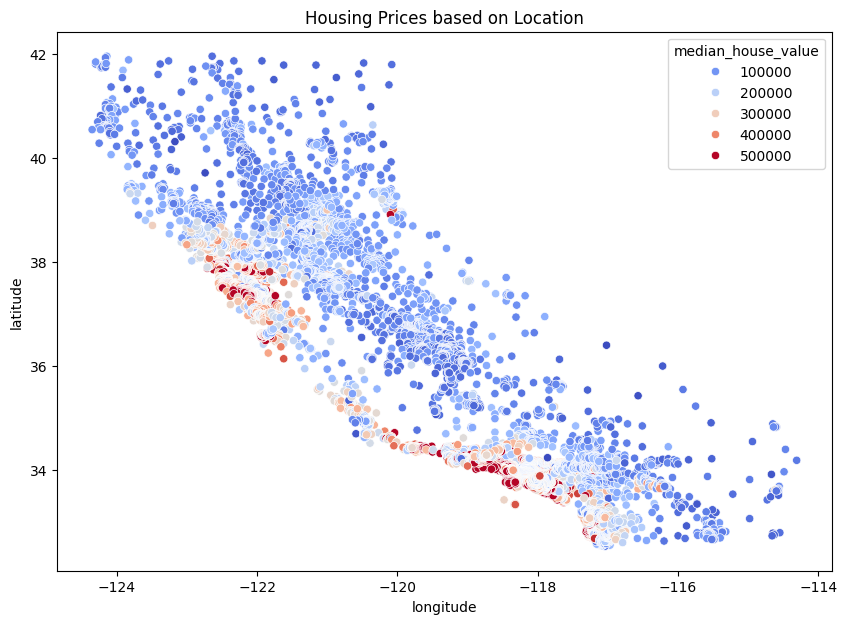

In [36]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=dataset, x="longitude", y="latitude", hue="median_house_value", palette="coolwarm")
plt.title("Housing Prices based on Location")
plt.show()

In [37]:
# 1. ocean_proximity ko numbers (dummy variables) mein convert karna
dataset = pd.get_dummies(dataset, columns=['ocean_proximity'])

In [38]:
# 2. Check karein ke naye columns ban gaye hain
print(dataset.head(1))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                      False                   False                   False   

   ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN  
0                      True                       False  


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [40]:
# Hum maujooda columns se naye ratios banayenge
dataset["rooms_per_household"] = dataset["total_rooms"] / dataset["households"]
dataset["bedrooms_per_room"] = dataset["total_bedrooms"] / dataset["total_rooms"]
dataset["population_per_household"] = dataset["population"] / dataset["households"]

In [41]:
# 1. Features (X) aur Target (y) ko alag karein
X = dataset.drop(['median_house_value'], axis=1) # Target ke ilawa baqi sab columns
y = dataset['median_house_value'] # Sirf target column (Price)

In [42]:
# 2. Data ko Train aur Test sets mein split karein (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
# 7. Final Accuracy Check
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred)

print(f"Updated R-squared Score: {accuracy}")

Updated R-squared Score: 0.8120237656447744
